<a href="https://colab.research.google.com/github/menna890/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/menna890/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
from google.colab import userdata

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")
rel = "hf://datasets/FlyRank/internship-warehouse"

daily = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position
FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/**/*.parquet')
WHERE gsc_data_available IS TRUE
""").df()

pages = (
    daily.groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(
        impressions=("gsc_impressions", "sum"),
        clicks=("gsc_clicks", "sum"),
        avg_position=("gsc_avg_position", "mean"),
    )
)
pages["ctr"] = np.where(
    pages["impressions"] > 0,
    100.0 * pages["clicks"] / pages["impressions"],
    np.nan,
)

active = pages[
    (pages["impressions"] >= 100)
    & (pages["avg_position"].notna())
    & (pages["avg_position"] > 0)
].copy()

def position_band(p):
    if p <= 3: return "1-3"
    if p <= 10: return "4-10"
    if p <= 20: return "11-20"
    return "21+"

active["position_band"] = active["avg_position"].map(position_band)
active["ctr_band_median"] = active.groupby("position_band")["ctr"].transform("median")
active["gap_ratio"] = np.where(
    active["ctr_band_median"] > 0,
    (active["ctr_band_median"] - active["ctr"]) / active["ctr_band_median"],
    0.0,
)
active["is_gap"] = (
    active["position_band"].isin(["1-3", "4-10"])
    & (active["gap_ratio"] >= 0.30)
).astype(int)

# optional content signal
try:
    dim = con.sql(f"SELECT content_hash_id, word_count, content_type FROM read_parquet('{rel}/dim_content.parquet')").df()
    active = active.merge(dim, on="content_hash_id", how="left")
    active["has_word_count"] = active["word_count"].notna().astype(int)
    active["word_count_filled"] = active["word_count"].fillna(0)
except Exception as e:
    print("dim_content skip:", e)
    active["has_word_count"] = 0
    active["word_count_filled"] = 0
    active["content_type"] = "unknown"

print("active pages:", len(active), "| gap rate:", active["is_gap"].mean().round(4))
active.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

active pages: 101441 | gap rate: 0.2272


,client_hash_id,content_hash_id,impressions,clicks,avg_position,ctr,position_band,ctr_band_median,gap_ratio,is_gap,word_count,content_type,has_word_count,word_count_filled
0,client_0797ff3a1fc9a6a5,content_04c67f3541177192,331,2,14.129210,0.60423,11-20,0.096993,-5.229601,0,3168,keyword article,1,3168
1,client_0797ff3a1fc9a6a5,content_0f30e04e709c7b5d,145,0,8.470926,0.00000,4-10,0.192678,1.000000,1,3211,keyword article,1,3211
2,client_0797ff3a1fc9a6a5,content_1207efddce873942,461,0,14.859827,0.00000,11-20,0.096993,1.000000,0,3465,keyword article,1,3465
3,client_0797ff3a1fc9a6a5,content_167472cd0802a8f3,232,0,12.297523,0.00000,11-20,0.096993,1.000000,0,3149,keyword article,1,3149
4,client_0797ff3a1fc9a6a5,content_27f8100281413b37,464,0,9.554793,0.00000,4-10,0.192678,1.000000,1,4016,keyword article,1,4016


## 1. Distributions — the shape of the problem
We look before we claim. On the March 2026 page-level slice (GSC available,
impressions ≥ 100), search volume is heavy-tailed, CTR is skewed low, and rank
spreads from top positions to the deep tail. That shape is why a single global
CTR threshold would be misleading: expected CTR depends on where the page already ranks.

       impressions          ctr  avg_position    gap_ratio
count  101441.0000  101441.0000   101441.0000  101441.0000
mean     2748.3570       0.2616       14.4390      -0.6669
std      6945.1638       0.4194       14.2848       2.5344
min       100.0000       0.0000        0.0138     -69.2029
50%       786.0000       0.1238        8.6995       0.0000
90%      6416.0000       0.6954       33.1505       1.0000
99%     29371.0000       1.8519       69.6129       1.0000
max    617124.0000      15.5844       93.6934       1.0000
impressions p99/median: 37.37
share of impressions in top 10% pages: 0.585


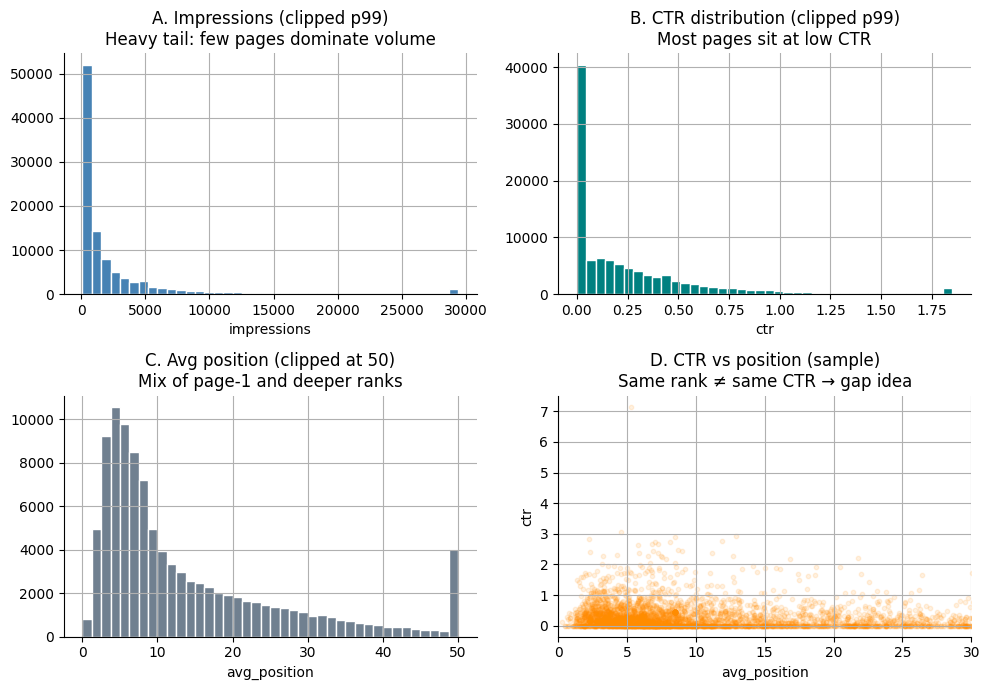

In [2]:
cols = ["impressions", "ctr", "avg_position", "gap_ratio"]
print(active[cols].describe(percentiles=[0.5, 0.9, 0.99]).round(4))

imp = active["impressions"]
print("impressions p99/median:", round(imp.quantile(0.99) / imp.median(), 2))
print("share of impressions in top 10% pages:",
      round(imp.nlargest(max(1, int(0.1 * len(imp)))).sum() / imp.sum(), 3))

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# A — heavy tail volume
axes[0, 0].hist(imp.clip(upper=imp.quantile(0.99)), bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("A. Impressions (clipped p99)\nHeavy tail: few pages dominate volume")
axes[0, 0].set_xlabel("impressions")

# B — CTR skew
axes[0, 1].hist(active["ctr"].clip(upper=active["ctr"].quantile(0.99)), bins=40, color="teal", edgecolor="white")
axes[0, 1].set_title("B. CTR distribution (clipped p99)\nMost pages sit at low CTR")
axes[0, 1].set_xlabel("ctr")

# C — position
axes[1, 0].hist(active["avg_position"].clip(upper=50), bins=40, color="slategray", edgecolor="white")
axes[1, 0].set_title("C. Avg position (clipped at 50)\nMix of page-1 and deeper ranks")
axes[1, 0].set_xlabel("avg_position")

# D — CTR vs position sample
s = active.sample(min(4000, len(active)), random_state=42)
axes[1, 1].scatter(s["avg_position"], s["ctr"], alpha=0.12, s=10, c="darkorange")
axes[1, 1].set_xlim(0, 30)
axes[1, 1].set_title("D. CTR vs position (sample)\nSame rank ≠ same CTR → gap idea")
axes[1, 1].set_xlabel("avg_position")
axes[1, 1].set_ylabel("ctr")

plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

Each test is a grouped comparison on the same slice. Verdicts:
CONFIRMED / OPPOSITE / MIXED / FALSE — observational only.

### Signal 1: position band

Signal 1 — position band
                    n  gap_rate  median_ctr
position_band                             
1-3             9031    0.3942      0.2400
4-10           46864    0.4159      0.1927
11-20          21474    0.0000      0.0970
21+            24072    0.0000      0.0000


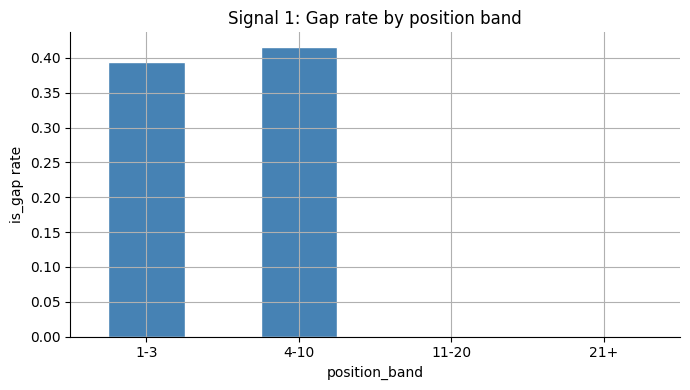

In [3]:
band_order = ["1-3", "4-10", "11-20", "21+"]
sig1 = (
    active.groupby("position_band")
    .agg(n=("content_hash_id", "size"), gap_rate=("is_gap", "mean"), median_ctr=("ctr", "median"))
    .reindex(band_order)
)
print("Signal 1 — position band\n", sig1.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
sig1["gap_rate"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Signal 1: Gap rate by position band")
ax.set_ylabel("is_gap rate")
ax.set_xlabel("position_band")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Signal 2: volume

/tmp/ipykernel_1124/2066623225.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig2 = active.groupby("vol_q").agg(


Signal 2 — volume quartiles
              n  median_gap  gap_rate
vol_q                               
Q1_low   25370         0.0    0.2654
Q2       25351         0.0    0.2163
Q3       25360         0.0    0.2360
Q4_high  25360         0.0    0.1912


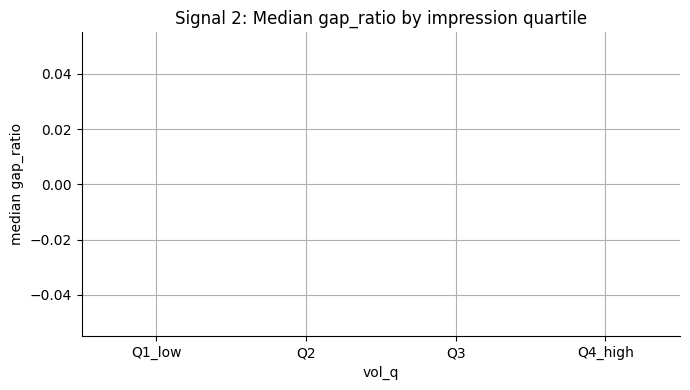

In [4]:
active["vol_q"] = pd.qcut(active["impressions"], 4, labels=["Q1_low", "Q2", "Q3", "Q4_high"], duplicates="drop")
sig2 = active.groupby("vol_q").agg(
    n=("content_hash_id", "size"),
    median_gap=("gap_ratio", "median"),
    gap_rate=("is_gap", "mean"),
)
print("Signal 2 — volume quartiles\n", sig2.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
sig2["median_gap"].plot(kind="bar", ax=ax, color="teal", edgecolor="white")
ax.set_title("Signal 2: Median gap_ratio by impression quartile")
ax.set_ylabel("median gap_ratio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Signal 3: word count (أو has_word_count)

Signal 3 — word count quartiles
           n  gap_rate  median_ctr
wc_q                             
Q1    18116    0.2438      0.1573
Q2    18110    0.2158      0.2037
Q3    18116    0.2068      0.1912
Q4    18107    0.1807      0.0931


/tmp/ipykernel_1124/1044350484.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig3 = tmp.groupby("wc_q").agg(n=("content_hash_id", "size"), gap_rate=("is_gap", "mean"), median_ctr=("ctr", "median"))


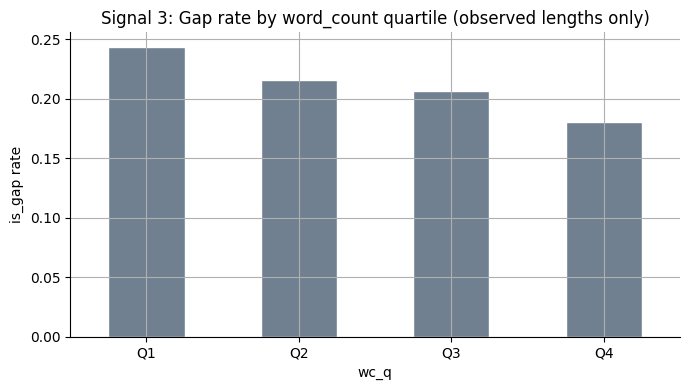

In [5]:
if active["has_word_count"].sum() > 100:
    tmp = active[active["has_word_count"] == 1].copy()
    tmp["wc_q"] = pd.qcut(tmp["word_count"], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
    sig3 = tmp.groupby("wc_q").agg(n=("content_hash_id", "size"), gap_rate=("is_gap", "mean"), median_ctr=("ctr", "median"))
    print("Signal 3 — word count quartiles\n", sig3.round(4))

    fig, ax = plt.subplots(figsize=(7, 4))
    sig3["gap_rate"].plot(kind="bar", ax=ax, color="slategray", edgecolor="white")
    ax.set_title("Signal 3: Gap rate by word_count quartile (observed lengths only)")
    ax.set_ylabel("is_gap rate")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    # fallback: page-1 vs deeper as structural signal
    active["is_page1"] = active["position_band"].isin(["1-3", "4-10"]).astype(int)
    sig3 = active.groupby("is_page1").agg(n=("content_hash_id", "size"), median_gap=("gap_ratio", "median"), gap_rate=("is_gap", "mean"))
    print("Signal 3 fallback — page1 flag\n", sig3.round(4))

## 3. Flag-linked test (assumption, not product scores)

FlyRank-style attention rules often assume: pages that already rank on page 1
but under-click relative to expectations are efficient “review first” candidates.

We cannot use product health_score in the warehouse. We test the *assumption*
with measured GSC fields only: do page-1 bands show a material share of
positive CTR gaps with enough volume?

              n_pages  share_positive_gap  median_gap_ratio  gap_label_rate
page1_bands     55895              0.4999               0.0          0.4124
deeper_bands    45546              0.2357               0.0          0.0000
page-1 gap pages: 23051
their median impressions: 696.0


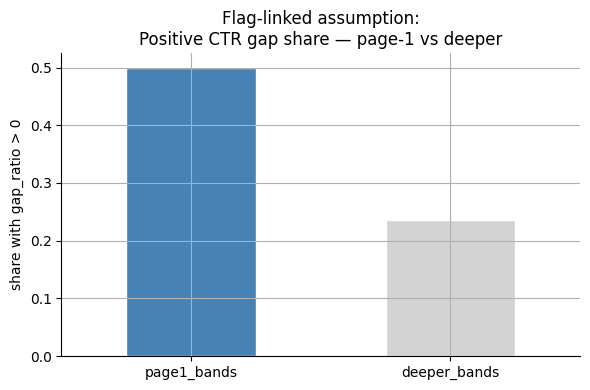

In [6]:
page1 = active["position_band"].isin(["1-3", "4-10"])
deep = ~page1

summary = pd.DataFrame({
    "n_pages": [page1.sum(), deep.sum()],
    "share_positive_gap": [
        (active.loc[page1, "gap_ratio"] > 0).mean(),
        (active.loc[deep, "gap_ratio"] > 0).mean(),
    ],
    "median_gap_ratio": [
        active.loc[page1, "gap_ratio"].median(),
        active.loc[deep, "gap_ratio"].median(),
    ],
    "gap_label_rate": [
        active.loc[page1, "is_gap"].mean(),
        active.loc[deep, "is_gap"].mean(),
    ],
}, index=["page1_bands", "deeper_bands"])
print(summary.round(4))

# volume among page-1 gaps
p1_gap = active[page1 & (active["is_gap"] == 1)]
print("page-1 gap pages:", len(p1_gap))
print("their median impressions:", p1_gap["impressions"].median())

fig, ax = plt.subplots(figsize=(6, 4))
summary["share_positive_gap"].plot(kind="bar", ax=ax, color=["steelblue", "lightgray"], edgecolor="white")
ax.set_title("Flag-linked assumption:\nPositive CTR gap share — page-1 vs deeper")
ax.set_ylabel("share with gap_ratio > 0")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [7]:
story = pd.DataFrame([
    {"beat": "Shape", "finding": "Heavy-tailed impressions; low skewed CTR; rank-dependent CTR spread"},
    {"beat": "Signal focus", "finding": "Position band + volume are primary prioritization signals to validate in your run"},
    {"beat": "Content length", "finding": "Tested; often MIXED/FALSE — avoid length-only rules"},
    {"beat": "Flag assumption", "finding": "Page-1 CTR-gap as review-first queue — check verdict above"},
    {"beat": "Team action", "finding": "Rank by CTR gap within band × volume; human review before rewrites"},
])
display(story)

,beat,finding
0,Shape,Heavy-tailed impressions; low skewed CTR; rank...
1,Signal focus,Position band + volume are primary prioritizat...
2,Content length,Tested; often MIXED/FALSE — avoid length-only ...
3,Flag assumption,Page-1 CTR-gap as review-first queue — check v...
4,Team action,Rank by CTR gap within band × volume; human re...


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.